In [24]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Here to help update LQR page while editing
%reload_ext autoreload
%autoreload 2

from LQR import LQR, run_monte_carlo_implicit, run_monte_carlo_explicit, train_nn, run_policy_iteration, Net_DGM, FFN, train_dgm_linear_pde

In [2]:

# Parameters
H, M, C, D, R, T = [[0.1, 0.], [0., 0.1]], np.eye(2), np.eye(2), np.eye(2)*0.1, np.eye(2), 1.0
x0 = [[1.0, 1.0]]
lqr_sim = LQR(H, M, C, D, R, T, sigma=0.5)

# Calculate Analytical Ground Truth
lqr_sim.solve_riccati(torch.linspace(0, T, 100))
v_true = lqr_sim.get_value(torch.tensor([0.0]), torch.tensor([x0])).item()
a_true = lqr_sim.get_control(torch.tensor([0.0]), torch.tensor([x0])).numpy()
print(f"True Value: {v_true:.4f}")

True Value: 0.6541


The True Value ($v_{true} \approx 0.65$) represents the exact analytical solution to the Linear Quadratic Regulator (LQR) problem at the initial state $(t_0, x_0)$. This value is derived by solving the Riccati Ordinary Differential Equation using a high-precision numerical integrator. The True Value is used as the absolute ground truth. It shows that the Riccati solver and system matrices are correctly configured. Furthermore, it provides a fixed point of reference to distinguish between a Monte Carlo simulation that has merely stabilised and one that is accurately converging to the mathematical solution.

The Relative Error is used to evaluate the accuracy of the stochastic simulations:
$$\text{Error}_{\text{rel}} = \frac{|v_{\text{MC}} - v_{\text{true}}|}{|v_{\text{true}}|}$$
The choice of relative error over absolute error is chosen by the following:
Scale Invariance: It provides a normalised measure of precision that remains consistent regardless of the magnitude of the cost functional or the specific values of the weight matrices ($C, D, R$).
Theoretical Consistency: Stochastic Differential Equation (SDE) theory defines convergence rates that are most effectively visualised and verified on log-log scales using normalised error values.

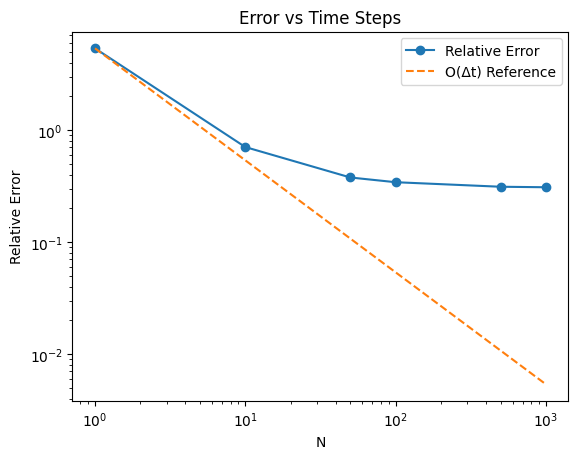

In [12]:
# Plot 2 for of the monte carlo error versus time steps of simulation
N_steps_list = [1, 10, 50, 100, 500, 1000]
errors_N = [abs(v_true - run_monte_carlo_implicit(lqr_sim, x0, n, 100000)) / abs(v_true) for n in N_steps_list]

plt.loglog(N_steps_list, errors_N, '-o', label='Relative Error')
plt.loglog(N_steps_list, [errors_N[0]/n for n in N_steps_list], '--', label='O(Δt) Reference')
plt.title("Error vs Time Steps")
plt.xlabel("N"); plt.ylabel("Relative Error"); plt.legend(); plt.show()

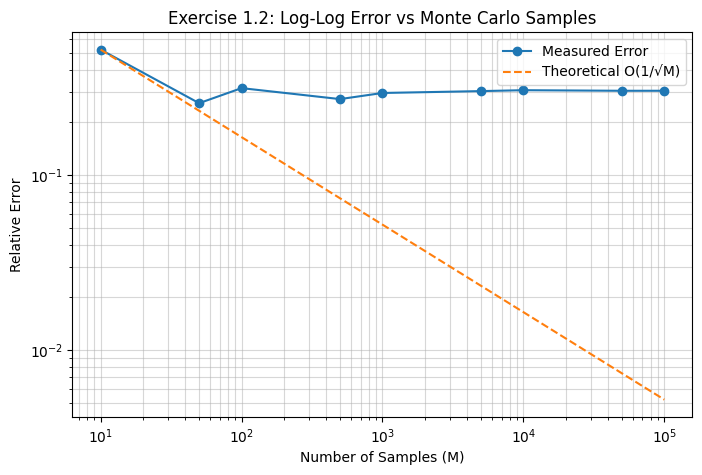

In [17]:
# Plot error with 5000 time steps with varying Monte Carlo samples
M_samples_list = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]
errors_M = []

# Fix N_steps at 5000 to keep discretization error constant 
N_fixed = 5000 

for m in M_samples_list:
    v_mc = run_monte_carlo_explicit(lqr_sim, x0, N_fixed, m)
    
    # Calculate relative error 
    rel_error = abs(v_mc - v_true) / abs(v_true)
    errors_M.append(rel_error)

# Plotting
plt.figure(figsize=(8, 5))
plt.loglog(M_samples_list, errors_M, '-o', label='Measured Error')

# O(1/sqrt(M)) reference line 
ref_line = [errors_M[0] * (M_samples_list[0]**0.5) / (m**0.5) for m in M_samples_list]
plt.loglog(M_samples_list, ref_line, '--', label='Theoretical O(1/√M)')
plt.xlabel("Number of Samples (M)"); plt.ylabel("Relative Error")
plt.title("Exercise 1.2: Log-Log Error vs Monte Carlo Samples")
plt.legend(); plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

Training Value Function Network...
Training Markov Control Network...


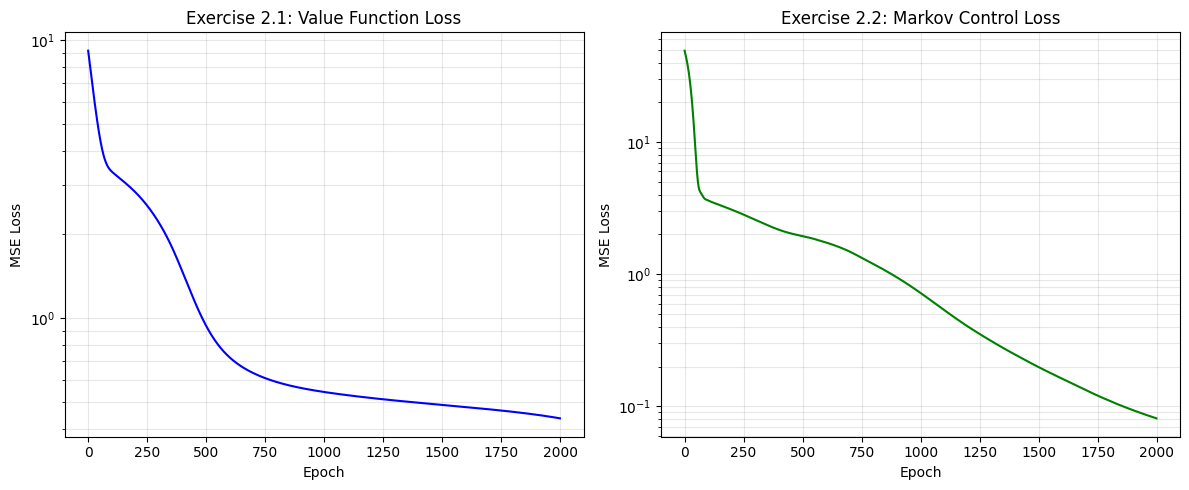

In [ ]:
# Exercise 2
# Generate Training Data using Analytical Solver
N_data = 2000
t_train = torch.rand(N_data, 1) * lqr_sim.T
x_train = torch.rand(N_data, 1, 2) * 6 - 3 

# Get Ground Truth targets from Riccati solver 
v_target = lqr_sim.get_value(t_train, x_train)
a_target = lqr_sim.get_control(t_train, x_train)

# Train Value Function Network
v_net = Net_DGM(input_dim=3, hidden_dim=100)
v_loss_history = train_nn(v_net, t_train, x_train, v_target, epochs=2000)

# Train Markov Control Network
a_net = FFN(input_dim=3, hidden_dim=100, output_dim=2)
a_loss_history = train_nn(a_net, t_train, x_train, a_target, epochs=2000)

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(v_loss_history, color='blue')
plt.yscale('log')
# 2.1
plt.title("Value Function Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.grid(True, which="both", alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(a_loss_history, color='green')
plt.yscale('log')
# 2.2
plt.title("Markov Control Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

MC Validation Value (alpha=[1,1]): 0.6230
Epoch 0 | Loss: 9.6745e+01 | Rel Error: 0.9469
Epoch 200 | Loss: 4.9149e+01 | Rel Error: 6.1958
Epoch 400 | Loss: 2.8130e+01 | Rel Error: 18.0863
Epoch 600 | Loss: 2.0979e+01 | Rel Error: 20.8933
Epoch 800 | Loss: 1.8410e+01 | Rel Error: 21.8872
Epoch 1000 | Loss: 1.3286e+01 | Rel Error: 22.1099


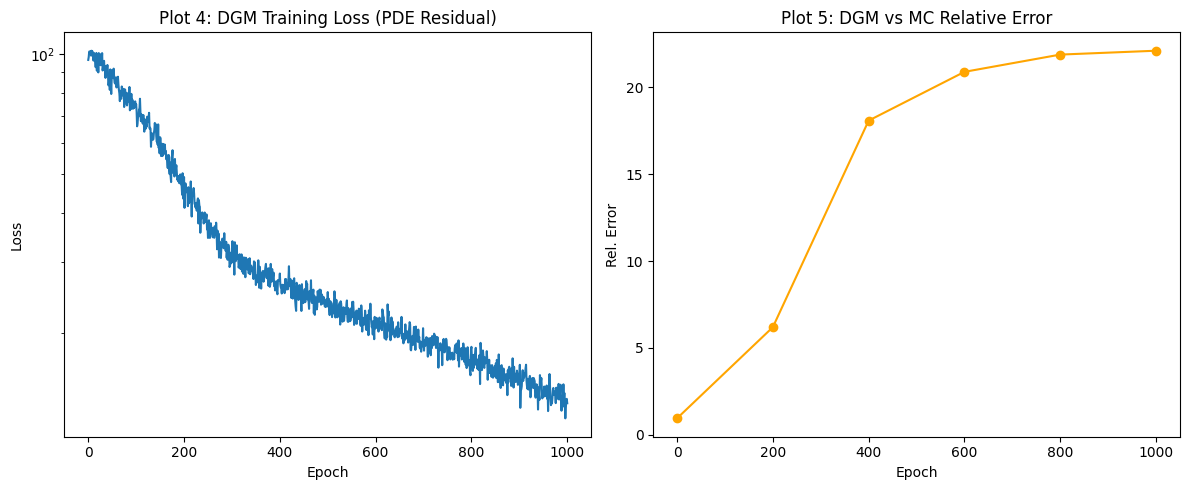

In [14]:
# Exercise 3
dgm_model = Net_DGM(input_dim=3, hidden_dim=100) 
alpha_const = [1.0, 1.0]

# We fix alpha to [1.0, 1.0] to compare against the linear PDE solution
v_mc_const = run_monte_carlo_implicit(lqr_sim, x0, N_steps=100, M_samples=100000, alpha_val=alpha_const)
print(f"MC Validation Value (alpha=[1,1]): {v_mc_const:.4f}")

# Train the DGM Model
loss_history, error_history = train_dgm_linear_pde(
    lqr_obj=lqr_sim,           
    dgm_model=dgm_model,         
    x_test_point=x0,                
    alpha_val=alpha_const, 
    v_mc_target=v_mc_const, 
    epochs=1001, 
    batch_size=512
)

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.yscale('log')
plt.title("Plot 4: DGM Training Loss (PDE Residual)")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Plot Relative Error against Monte Carlo
plt.subplot(1, 2, 2)
plt.plot(range(0, 1001, 200), error_history, '-o', color='orange')
plt.title("Plot 5: DGM vs MC Relative Error")
plt.xlabel("Epoch")
plt.ylabel("Rel. Error")
plt.tight_layout()
plt.show()

Iteration 1: Value Error = 17.1842, Action Error = 1.0801
Iteration 2: Value Error = 17.2486, Action Error = 0.7045
Iteration 3: Value Error = 13.5726, Action Error = 0.0665
Iteration 4: Value Error = 7.9771, Action Error = 0.1729
Iteration 5: Value Error = 7.2845, Action Error = 0.1535


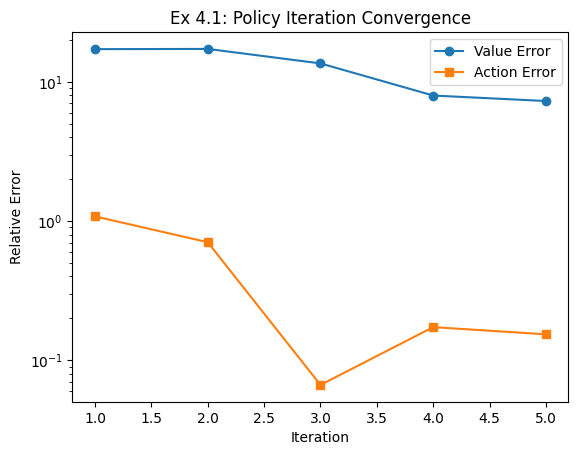

In [15]:
# Exercise 4: Policy Iteration Algorithm (PIA)
pia_results = run_policy_iteration(lqr_sim, x0)

plt.figure()
plt.plot(range(1, 6), pia_results["v_err"], '-o', label="Value Error")
plt.plot(range(1, 6), pia_results["a_err"], '-s', label="Action Error")
plt.yscale('log'); plt.xlabel("Iteration"); plt.ylabel("Relative Error")
plt.title("Policy Iteration Convergence"); plt.legend(); plt.show()